In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn import model_selection
from sklearn import linear_model #линейные модели
from sklearn import metrics
from sklearn import ensemble
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

ModuleNotFoundError: No module named 'catboost'

In [ ]:
df = pd.read_csv('AirPass.csv')
df = df.drop('Unnamed: 0',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     1039

In [ ]:
#Сколько всего в данных пропущенных значений?
df.isna().sum()#.sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [ ]:
# Заполните пропуски медианными значениями. После этого вычислите среднее арифметическое для признака, 
# отражающего задержку при прибытии в минутах.
df_col_na = df.columns[df.isna().any()]
df[df_col_na] = df[df_col_na].fillna(df[df_col_na].median())
print('Average ar delay: {:.2f}'.format(df['Arrival Delay in Minutes'].mean(), 2))

Average ar delay: 15.13


In [ ]:
df.groupby('Gender')['satisfaction'].value_counts()

Gender  satisfaction           
Female  neutral or dissatisfied    30193
        satisfied                  22534
Male    neutral or dissatisfied    28686
        satisfied                  22491
Name: count, dtype: int64

In [ ]:
df.groupby('Type of Travel')['satisfaction'].value_counts()

Type of Travel   satisfaction           
Business travel  satisfied                  41746
                 neutral or dissatisfied    29909
Personal Travel  neutral or dissatisfied    28970
                 satisfied                   3279
Name: count, dtype: int64

In [ ]:
df.groupby('Class')['satisfaction'].value_counts(normalize=True)

Class     satisfaction           
Business  satisfied                  0.694251
          neutral or dissatisfied    0.305749
Eco       neutral or dissatisfied    0.813862
          satisfied                  0.186138
Eco Plus  neutral or dissatisfied    0.753936
          satisfied                  0.246064
Name: proportion, dtype: float64

In [ ]:
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [ ]:
#Сколько теперь признаков в данных, если считать целевую переменную?
categoricals = df.select_dtypes(include = 'object').keys()
df_coded = pd.get_dummies(df, columns=categoricals)
df_coded.shape[1]

26

In [ ]:
X = df_coded.drop(['satisfaction'], axis=1)
y = df_coded['satisfaction']

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=26)
#print(X_train.shape)
#print(X_test.shape)

In [ ]:
#Разбейте данные на обучающую и тестовую выборки в соотношении 80/20, параметр random_state = 26. Сколько наблюдений попало в тестовую выборку?
X_test.shape[0]

20781

In [ ]:
#Теперь нам необходимо реализовать масштабирование данных. 
#Для этого обучите на обучающей выборке метод StandardScaler() и с помощью него преобразуйте и обучающую, и тестовую выборки.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
round(X_test_scaled[0][0], 2)


np.float64(0.93)

In [ ]:
#Обучите логистическую регрессию с параметрами по умолчанию на наших данных. В качестве ответа введите значение метрики f1_score.
logreg = linear_model.LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
print('F1 score: {:.3f}'.format(metrics.f1_score(y_test, y_pred)))

F1 score: 0.855


In [ ]:
#Nеперь перейдём к бустингу. Начнём с обучения первой модели — AdaBoost. 
#В качестве базовой модели для неё возьмите решающее дерево с параметром random_state = 26.
#Обучите AdaBoost, зафиксировав random_state со значением 26 и задав темп обучения 0.01. 
# В качестве ответа введите значение метрики f1_score.
ADA = ensemble.AdaBoostClassifier(
    estimator=tree.DecisionTreeClassifier(random_state = 26), 
    learning_rate=0.01, 
    random_state=26)
ADA.fit(X_train_scaled, y_train)
y_pred = ADA.predict(X_test_scaled)
print('F1 score: {:.3f}'.format(metrics.f1_score(y_test, y_pred)))

F1 score: 0.940


In [ ]:
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}

grid_forest = model_selection.GridSearchCV(
    estimator = ensemble.GradientBoostingClassifier(), 
    param_grid=params, 
    cv=3,
    n_jobs = -1,
    scoring='f1'
) 

In [ ]:
grid_forest.fit(X_train_scaled, y_train) 
y_pred_tree_1 = grid_forest.predict(X_train_scaled)
print('Best f1 score: {:.3f}'.format(grid_forest.best_score_))


Best f1 score: 0.949


In [ ]:
# Обучите алгоритм XGBoost. Так как он достаточно мощный «из коробки», определите его с параметрами по умолчанию, 
# только задайте random_state = 26. Какое значение метрики f1_score получилось?
XGBoost = XGBClassifier(random_state = 26)
XGBoost.fit(X_train_scaled, y_train) 
y_pred_XBG = XGBoost.predict(X_train_scaled)
print('F1 score: {:.3f}'.format(metrics.f1_score(y_train, y_pred_XBG)))


F1 score: 0.976


<Axes: >

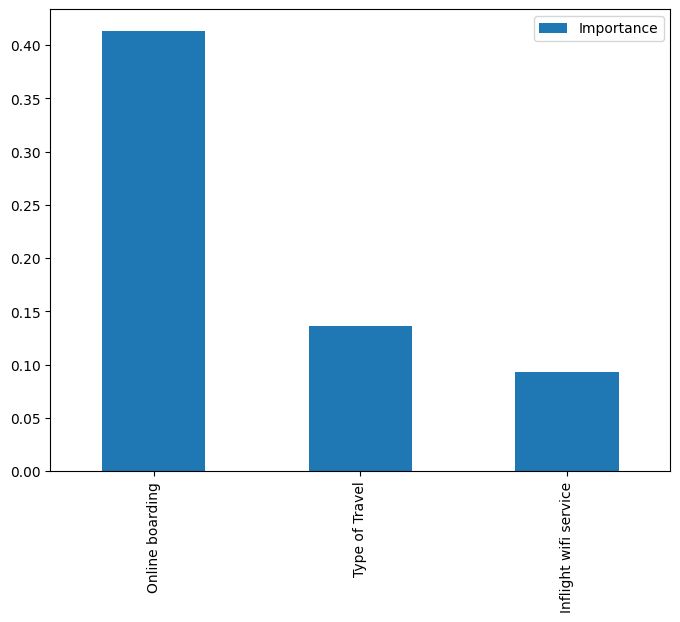

In [ ]:
feat_importances = pd.DataFrame(XGBoost.feature_importances_, index=X_train.columns, columns=["Importance"])
feat_importances.sort_values(by='Importance', ascending=False, inplace=True)
#print(feat_importances.head(3))
feat_importances.head(3).plot(kind='bar', figsize=(8,6))